In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from functools import reduce
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import scipy.stats as stats
from scipy.stats import jarque_bera, shapiro

import statsmodels.api as sm


C:\Users\DELL\AppData\Local\Temp\ipykernel_46008\506560858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


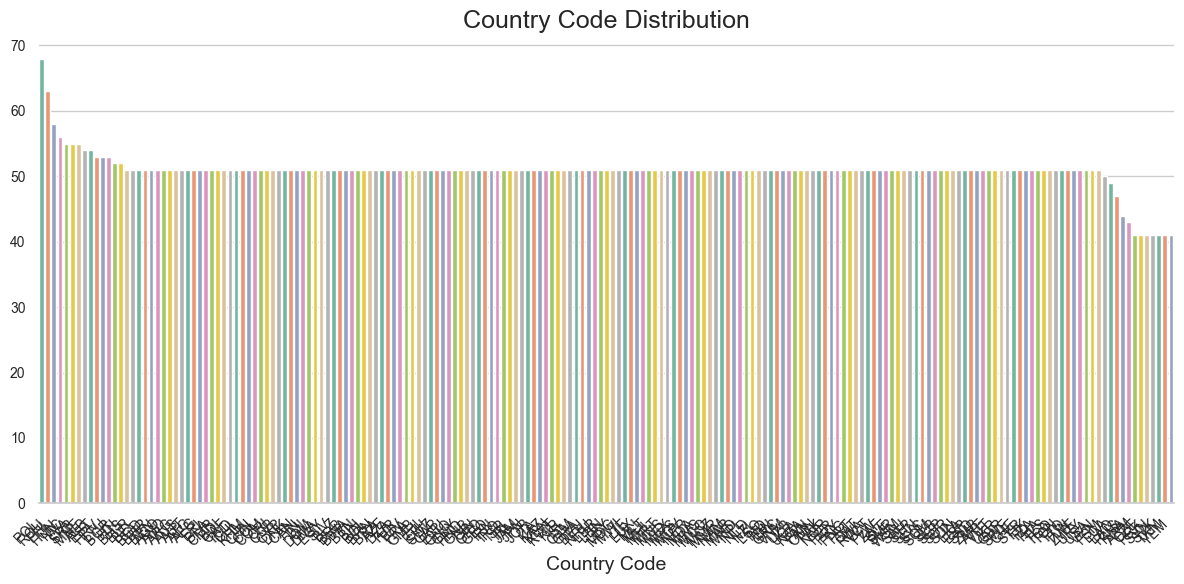

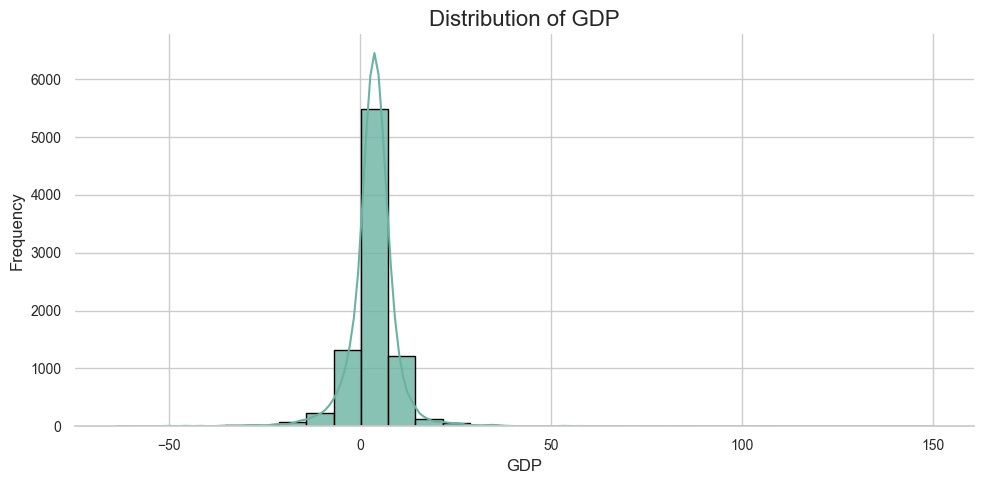

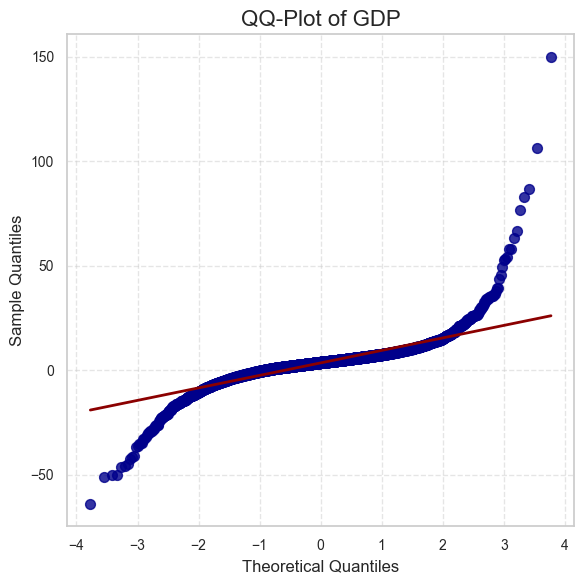

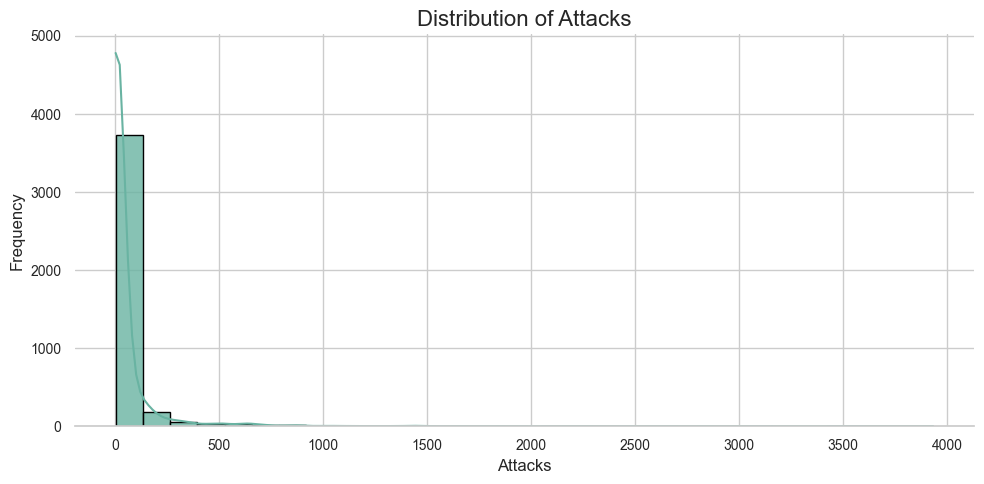

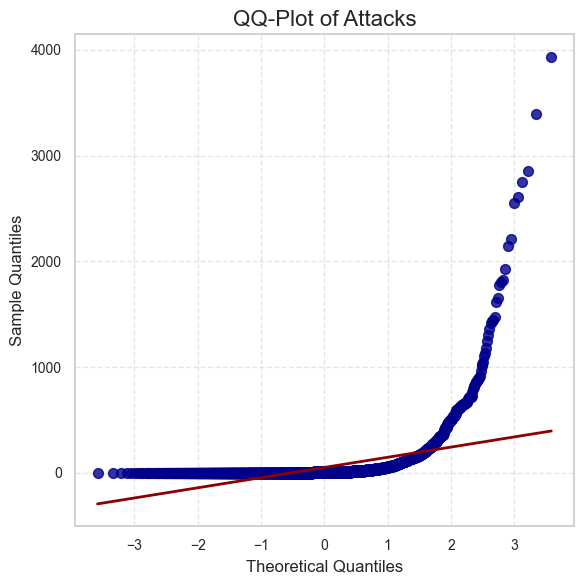

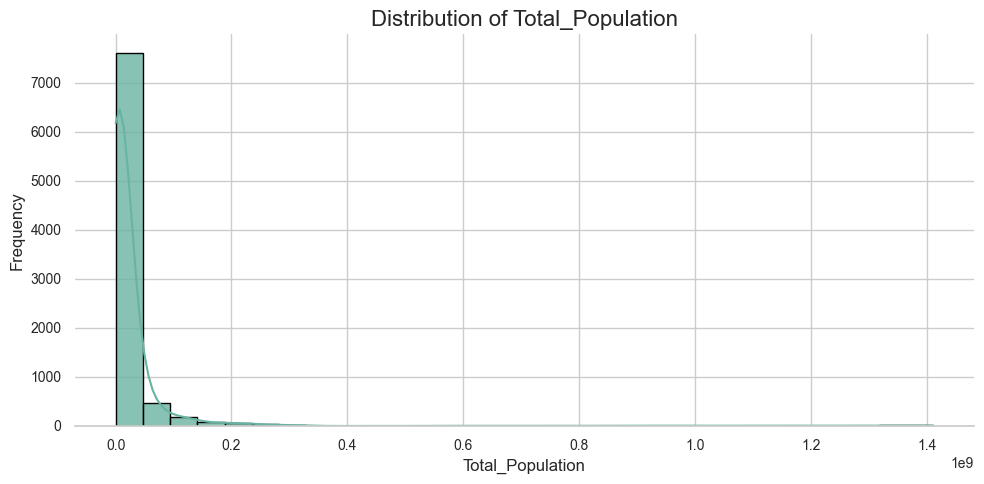

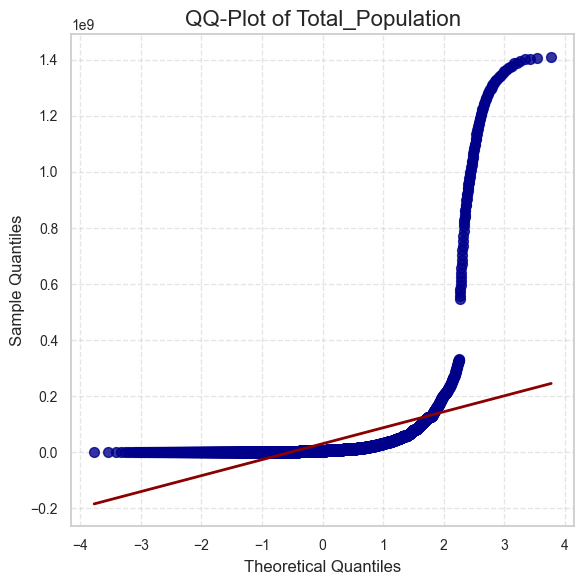

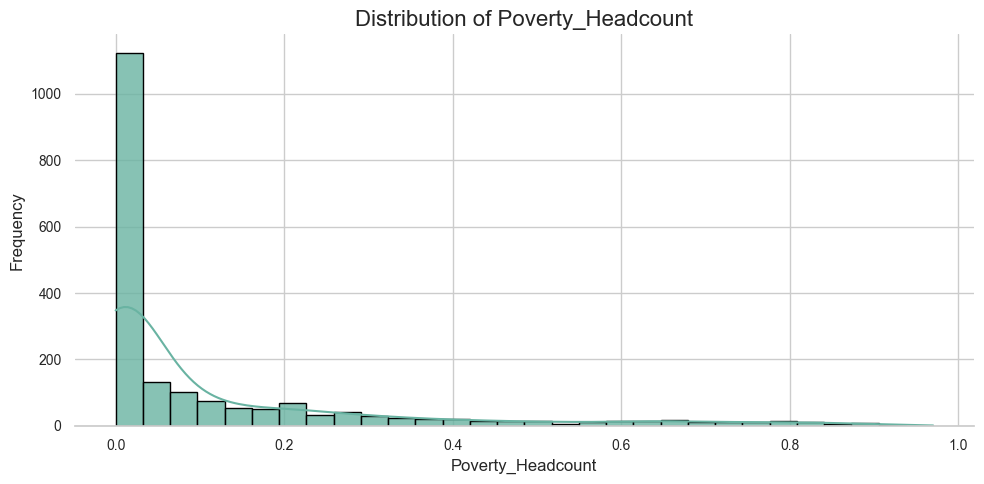

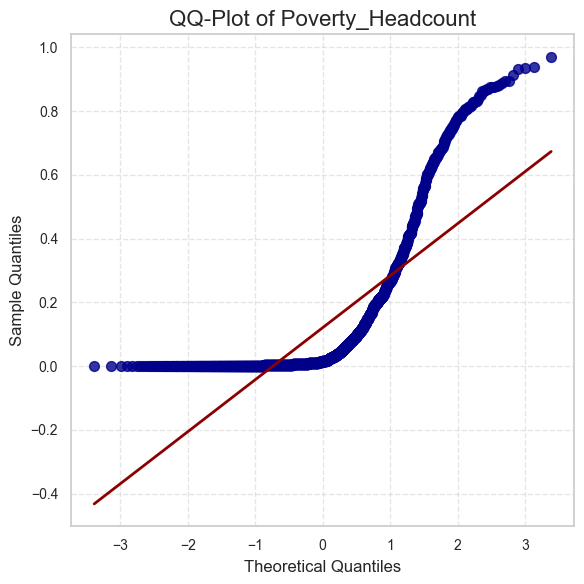

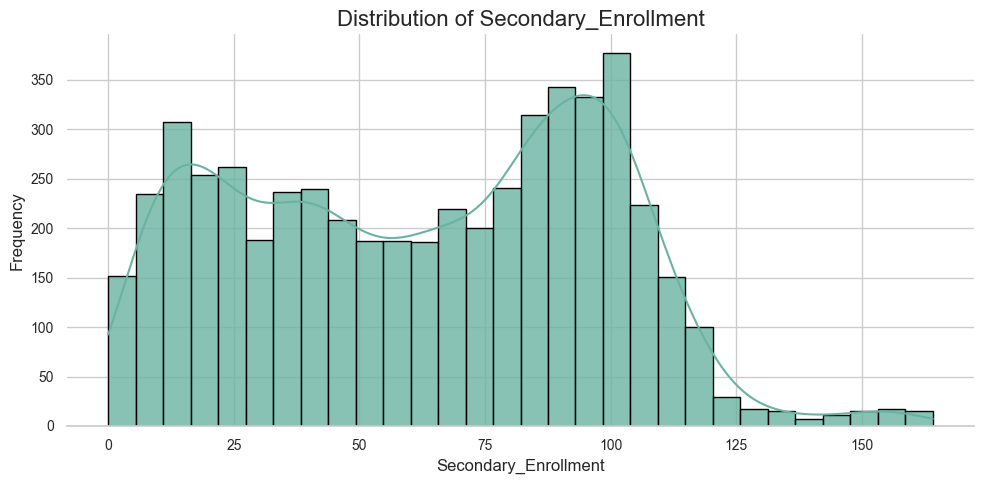

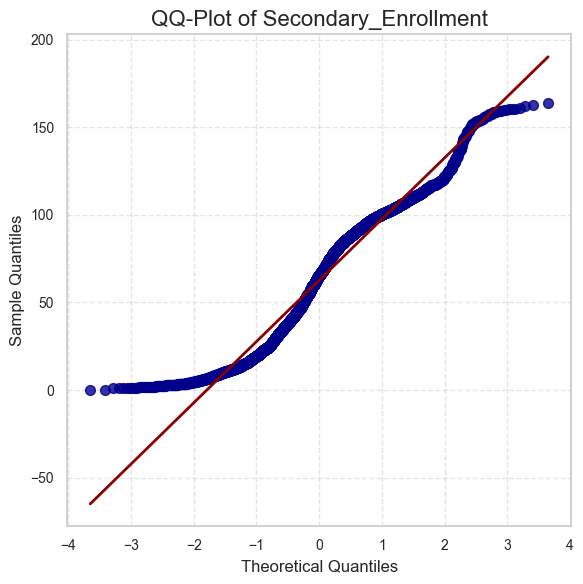

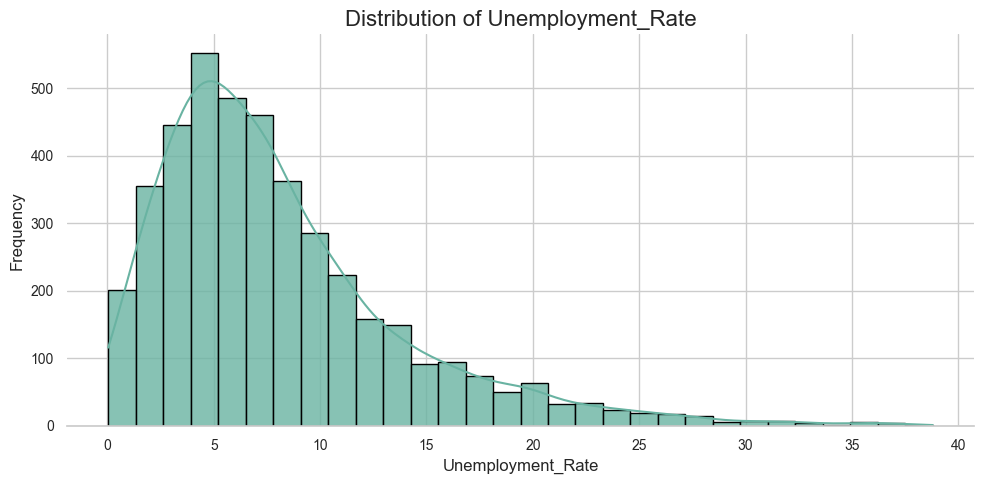

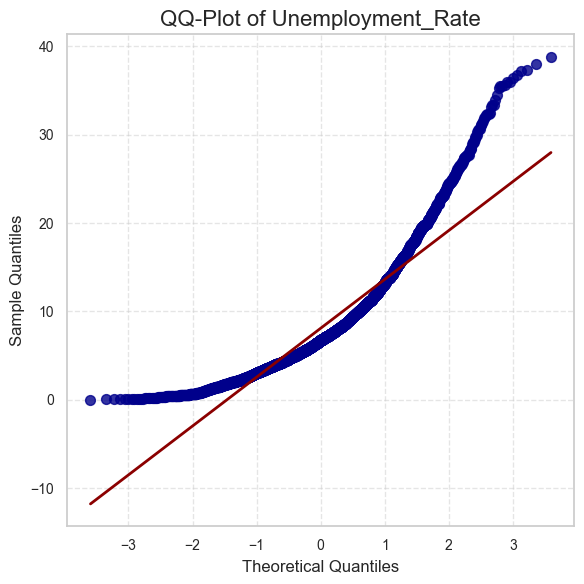

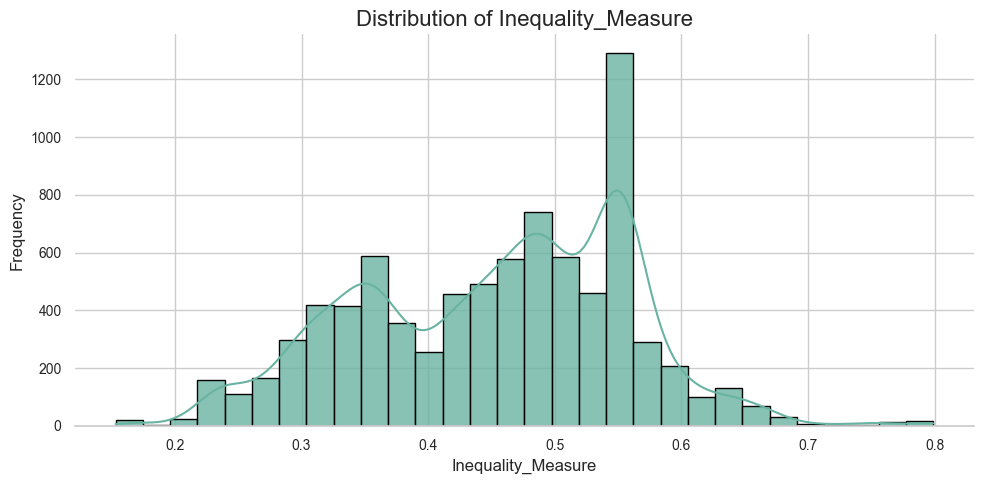

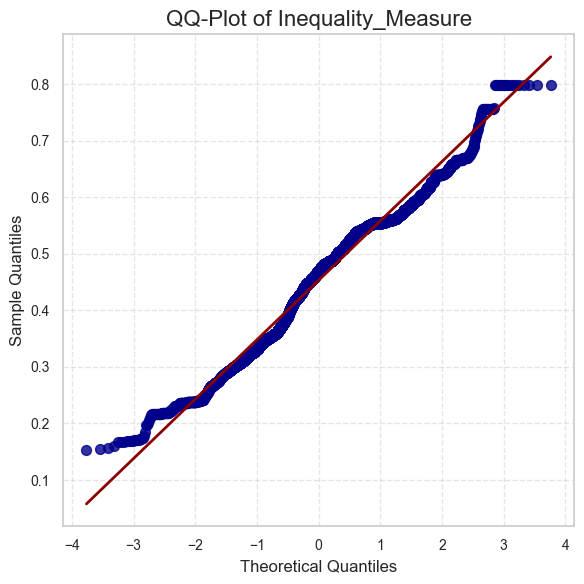

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()  # remove extra spaces

# Numeric columns
numeric_cols = ['GDP', 'Attacks', 'Total_Population', 'Poverty_Headcount',
                'Secondary_Enrollment', 'Unemployment_Rate', 'Inequality_Measure']

# Convert numeric columns to float
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Categorical columns to plot
categorical_cols = ['Country Code']

# Set Seaborn style for modern aesthetic
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# ---- CATEGORICAL PLOTS ----
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
    
    # Optional: add soft outlines to bars
    for patch in ax.patches:
        patch.set_edgecolor('white')
    
    plt.title(f"{col} Distribution", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("")  # remove y-axis label for cleaner look
    plt.xticks(rotation=45, ha='right')
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.show()

# ---- NUMERIC PLOTS + QQ PLOTS ----
for col in numeric_cols:
    if df[col].dropna().empty:
        continue  # skip empty columns

    # Histogram with KDE
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color="#69b3a2", edgecolor='black', alpha=0.8)
    plt.title(f"Distribution of {col}", fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    sns.despine(left=True)
    plt.tight_layout()
    plt.show()
    
    # ---- QQ-plot with darker points and line ----
    plt.figure(figsize=(6, 6))
    res = stats.probplot(df[col].dropna(), dist="norm")

    # Scatter points
    plt.scatter(res[0][0], res[0][1], color='darkblue', s=50, alpha=0.8)

    # Fit line
    slope, intercept = res[1][0], res[1][1]
    plt.plot(res[0][0], slope*res[0][0] + intercept, color='darkred', lw=2)

    plt.title(f"QQ-Plot of {col}", fontsize=16)
    plt.xlabel("Theoretical Quantiles", fontsize=12)
    plt.ylabel("Sample Quantiles", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


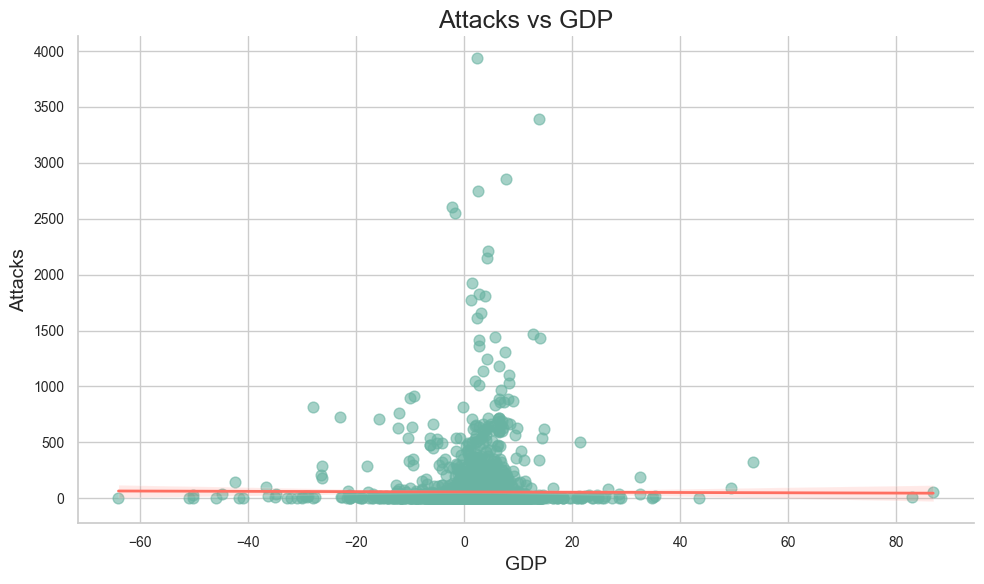

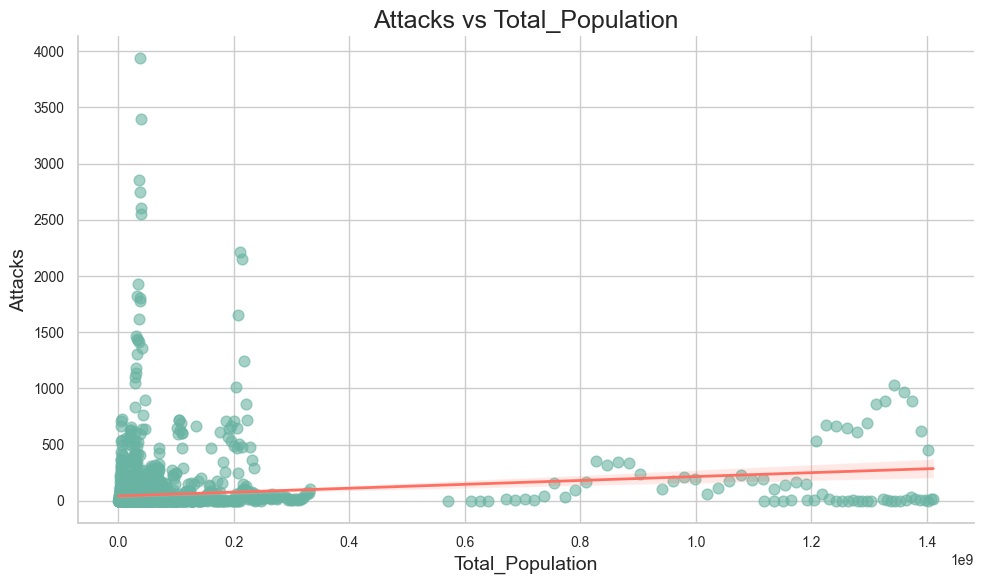

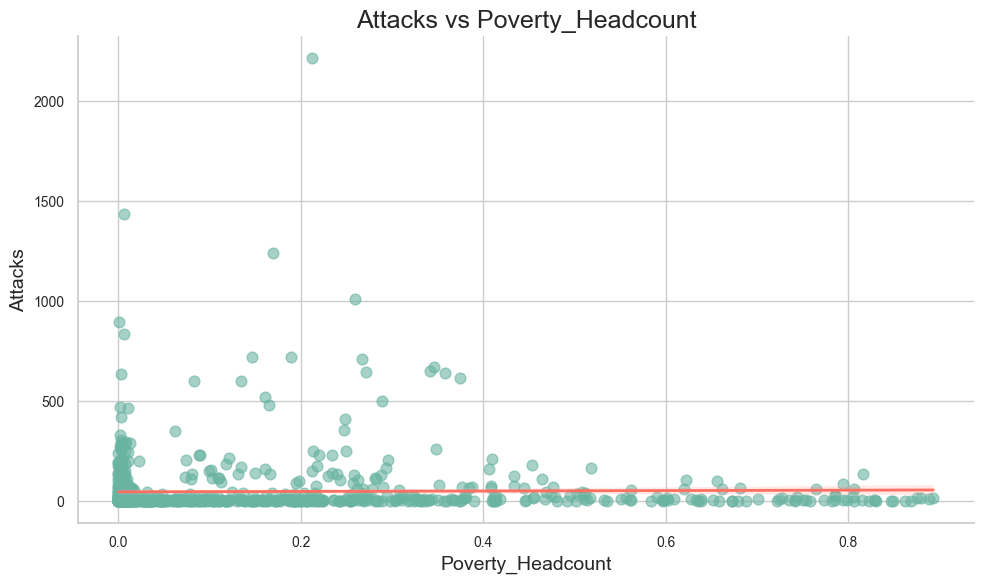

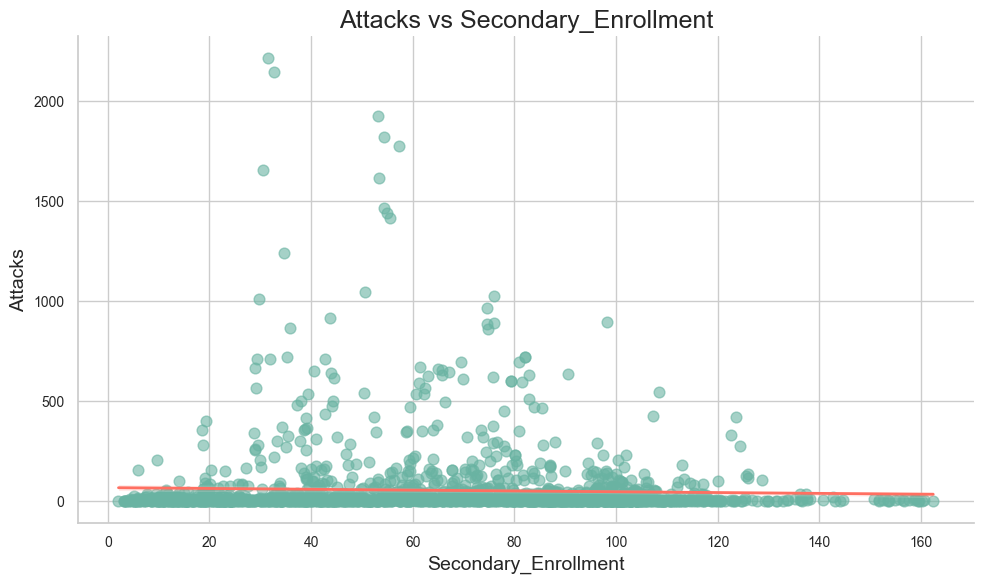

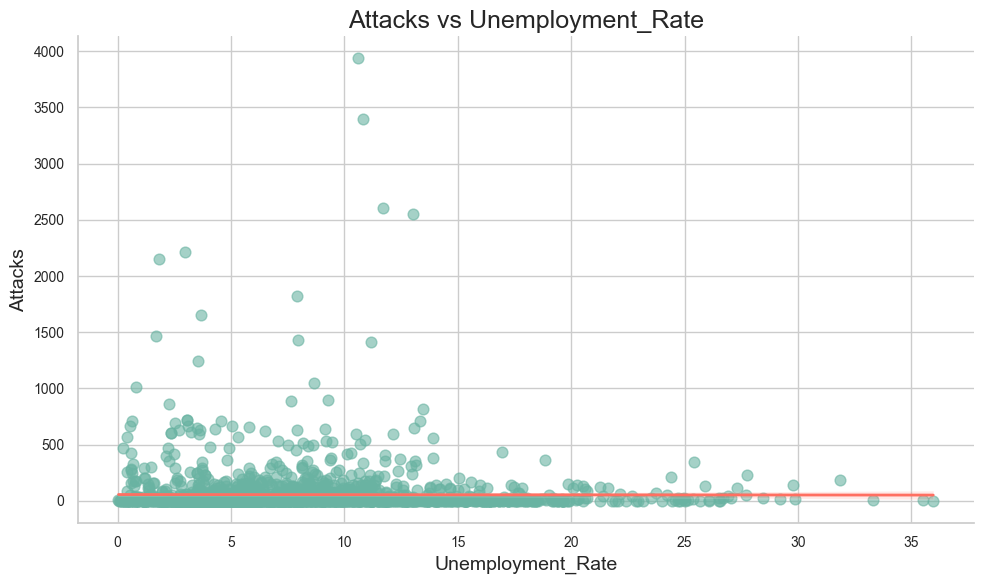

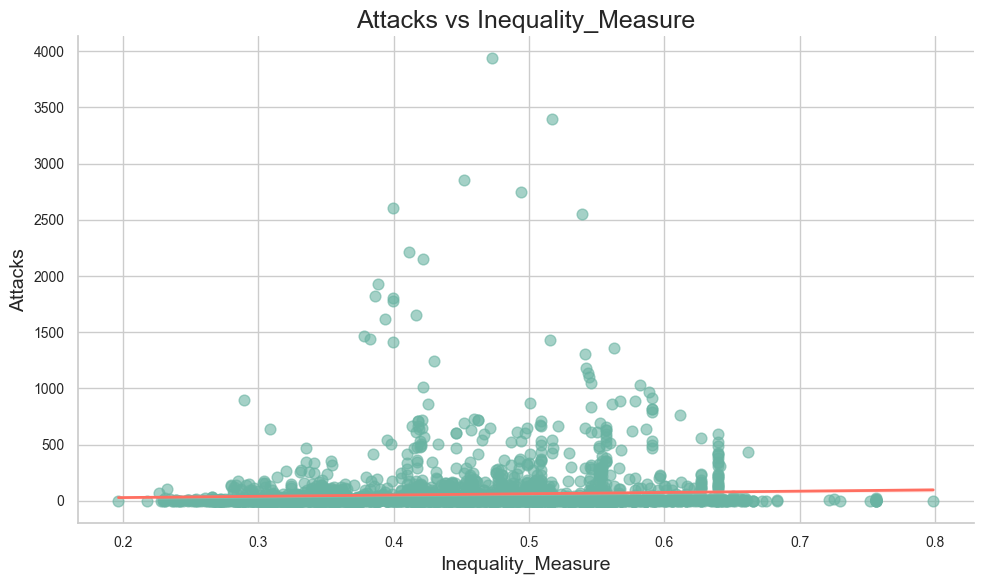

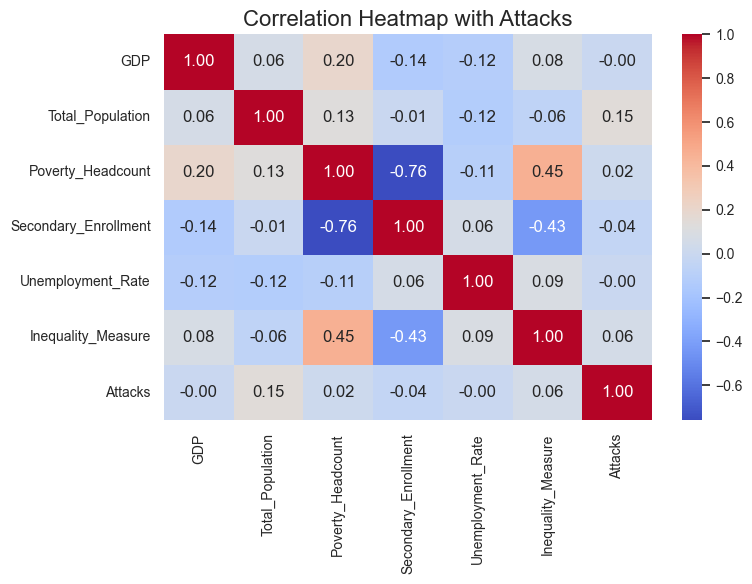

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel(r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\Final_Master_Panel_AllColumns.xlsx")
df.columns = df.columns.str.strip()  # remove extra spaces

# Numeric columns
numeric_cols = ['GDP', 'Total_Population', 'Poverty_Headcount',
                'Secondary_Enrollment', 'Unemployment_Rate', 'Inequality_Measure']

# Convert numeric columns to float
for col in numeric_cols + ['Attacks']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'axes.titlesize': 16, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

# ---- Scatterplots with regression line ----
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.regplot(
        x=col, 
        y='Attacks', 
        data=df, 
        scatter_kws={'alpha':0.6, 's':60, 'color':'#69b3a2'}, 
        line_kws={'color':'#ff6f61', 'lw':2}
    )
    plt.title(f"Attacks vs {col}", fontsize=18)
    plt.xlabel(col, fontsize=14)
    plt.ylabel("Attacks", fontsize=14)
    sns.despine()
    plt.tight_layout()
    plt.show()

# ---- Optional: Correlation Heatmap ----
plt.figure(figsize=(8,6))
corr = df[numeric_cols + ['Attacks']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap with Attacks", fontsize=16)
plt.tight_layout()
plt.show()
